# RE2.2 · El pipeline en marcha: curvas, costo y artefactos de cada corrida

Lo que dejan las corridas de `runs/`: curvas de entrenamiento (`metrics.jsonl`, `results.csv` de
Ultralytics), horas de GPU por época según los tiempos del `train.log`, y qué contiene un
checkpoint. Figuras y cifras para `RE_2-2_pipeline.tex`.

In [1]:
import json
import re
import subprocess
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import reporte
import torch
from reporte import PROJECT_DIR, TEXT_WIDTH_IN, number

from core.config import RUNS_DIR
from evaluation.metrics import MATCH_IOU
from training.yolo import FITNESS, RESULTS

OUT = reporte.out_dir("RE_2-2")
RUNS = {
    "detr_t10_logmel_v2": ("AST-Def-DETR log-mel", "#1e40af"),
    "detr_t10_logmel_birds": ("AST-Def-DETR aves", "#7c3aed"),
    "detr_t10_pcen_v2": ("AST-Def-DETR PCEN", "#00b4d8"),
    "detr_resnet": ("ResNet-50 Def-DETR", "#22c55e"),
    "frcnn_v2": ("Faster R-CNN", "#ff5fa2"),
    "yolo26s_v2": ("YOLO26s", "#f59e0b"),
}
EPOCH_LINE = re.compile(
    r"^\[(?P<stamp>[^\]]+)\] \[INFO\] \[training\.trainer\] \[\s*(?P<epoch>\d+)/(?P<total>\d+)\]"
)

In [2]:
# Curvas de los modelos del proyecto (Trainer) y de YOLO (Ultralytics), en un mismo marco.
def project_curves(run: str) -> pd.DataFrame:
    records = [
        json.loads(line) for line in (RUNS_DIR / run / "metrics.jsonl").read_text().splitlines()
    ]
    return pd.DataFrame(
        {
            "epoch": [r["epoch"] for r in records],
            "train_loss": [r["train"]["total"] for r in records],
            "val_loss": [r["val_loss"]["total"] for r in records],
            "map_30": [r["val"]["map_30"] for r in records],
            "recall": [r["val"]["recall"] for r in records],
            "precision": [r["val"]["precision"] for r in records],
        }
    )


def yolo_curves(run: str) -> pd.DataFrame:
    results = pd.read_csv(RUNS_DIR / run / RESULTS)
    results.columns = [c.strip() for c in results.columns]
    loss_columns = [c for c in results.columns if c.startswith("train/")]
    val_columns = [c for c in results.columns if c.startswith("val/")]
    return pd.DataFrame(
        {
            "epoch": results["epoch"],
            "train_loss": results[loss_columns].sum(axis=1),
            "val_loss": results[val_columns].sum(axis=1),
            "fitness": (results[list(FITNESS)] * pd.Series(FITNESS)).sum(axis=1),
            "recall": results["metrics/recall(B)"],
            "precision": results["metrics/precision(B)"],
        }
    )


curves = {run: yolo_curves(run) if run.startswith("yolo") else project_curves(run) for run in RUNS}
best_epoch = {
    run: int(
        torch.load(RUNS_DIR / run / "best.pt", map_location="cpu", weights_only=False)["epoch"]
    )
    + 1
    for run in RUNS
}
best_epoch

{'detr_t10_logmel_v2': 20,
 'detr_t10_logmel_birds': 15,
 'detr_t10_pcen_v2': 27,
 'detr_resnet': 25,
 'frcnn_v2': 4,
 'yolo26s_v2': 19}

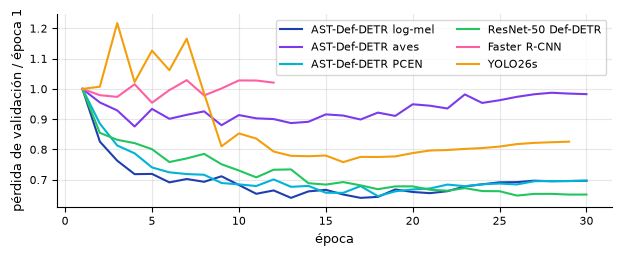

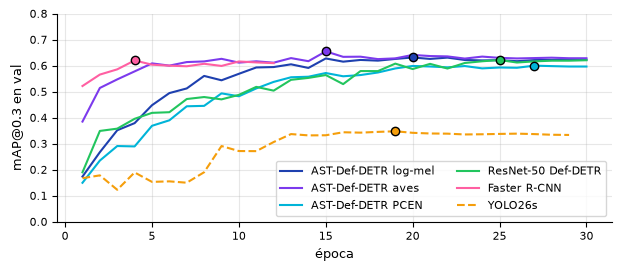

In [3]:
# Dos imágenes del ancho del texto: pérdida de validación relativa a la primera época y la
# métrica de validación con la época elegida marcada.
fig_loss, ax_loss = plt.subplots(figsize=(TEXT_WIDTH_IN, 2.4), constrained_layout=True)
fig_map, ax_map = plt.subplots(figsize=(TEXT_WIDTH_IN, 2.6), constrained_layout=True)
for run, (label, color) in RUNS.items():
    table = curves[run]
    metric = "fitness" if "fitness" in table else "map_30"
    ax_loss.plot(
        table["epoch"], table["val_loss"] / table["val_loss"].iloc[0], color=color, label=label
    )
    ax_map.plot(
        table["epoch"],
        table[metric],
        color=color,
        label=label,
        linestyle="--" if metric == "fitness" else "-",
    )
    ax_map.scatter(
        [best_epoch[run]],
        [table.loc[table["epoch"] == best_epoch[run], metric].iloc[0]],
        color=color,
        s=36,
        zorder=3,
        edgecolor="black",
    )
ax_loss.set(xlabel="época", ylabel="pérdida de validación / época 1")
ax_loss.legend(loc="upper right", ncol=2)
ax_map.set(xlabel="época", ylabel=f"mAP@{MATCH_IOU} en val", ylim=(0, 0.8))
ax_map.legend(loc="lower right", ncol=2)
reporte.save_figure(fig_loss, OUT / "curvas_perdida")
reporte.save_figure(fig_map, OUT / "curvas_map")
plt.show()

In [4]:
# Costo: minutos por época según las marcas de tiempo del train.log; YOLO trae el tiempo en results.csv.
def epoch_minutes(run: str) -> pd.Series:
    stamps = []
    for line in (RUNS_DIR / run / "train.log").read_text().splitlines():
        if (found := EPOCH_LINE.match(line)) is not None:
            stamps.append(
                (int(found["epoch"]), datetime.strptime(found["stamp"], "%Y-%m-%d %H:%M:%S"))
            )
    frame = pd.DataFrame(stamps, columns=["epoch", "stamp"]).drop_duplicates("epoch")
    minutes = frame["stamp"].diff().dt.total_seconds() / 60
    return minutes.loc[minutes.between(1, 600)]  # una pausa o un reinicio no es una época


cost = []
for run, (label, _) in RUNS.items():
    if run.startswith("yolo"):
        results = pd.read_csv(RUNS_DIR / run / RESULTS)
        results.columns = [c.strip() for c in results.columns]
        minutes = results["time"].diff().fillna(results["time"].iloc[0]) / 60
    else:
        minutes = epoch_minutes(run)
    n_epochs = len(curves[run])
    cost.append(
        (
            label,
            n_epochs,
            best_epoch[run],
            float(minutes.median()),
            float(minutes.median() * n_epochs / 60),
        )
    )
cost = pd.DataFrame(
    cost, columns=["configuración", "épocas", "mejor época", "min/época", "h total"]
)
reporte.write_rows(
    OUT / "costo.tex",
    [
        (
            r.configuración,
            number(r.épocas),
            number(r["mejor época"]),
            number(r["min/época"]),
            number(r["h total"], 1),
        )
        for _, r in cost.iterrows()
    ],
)
cost.round(1)

,configuración,épocas,mejor época,min/época,h total
0,AST-Def-DETR log-mel,30,20,40.4,20.2
1,AST-Def-DETR aves,30,15,13.4,6.7
2,AST-Def-DETR PCEN,30,27,40.6,20.3
3,ResNet-50 Def-DETR,30,25,61.7,30.8
4,Faster R-CNN,12,4,73.1,14.6
5,YOLO26s,29,19,4.3,2.1


In [5]:
# Qué deja una corrida y qué lleva un checkpoint.
run_dir = RUNS_DIR / "detr_t10_logmel_v2"
checkpoint = torch.load(run_dir / "best.pt", map_location="cpu", weights_only=False)
contents = {
    key: (
        f"{len(value)} tensores"
        if key == "state_dict"
        else f"{len(value)} clases"
        if key == "labels"
        else type(value).__name__
    )
    for key, value in checkpoint.items()
}
files = sorted(p.name for p in run_dir.iterdir())
reporte.write_rows(
    OUT / "checkpoint.tex",
    [(f"\\texttt{{{k.replace('_', '\\_')}}}", v) for k, v in contents.items()],
)
print(files)
contents

['best.pt', 'config.json', 'detr_t10_logmel_v2_test_predictions.pt', 'detr_t10_logmel_v2_val_predictions.pt', 'last.pt', 'metrics.jsonl', 'operating_point.json', 'train.log']


{'architecture': 'str',
 'hparams': 'dict',
 'labels': '25 clases',
 'config': 'dict',
 'state_dict': '398 tensores',
 'epoch': 'int',
 'metrics': 'dict'}

In [6]:
sizes = {run: (RUNS_DIR / run / "best.pt").stat().st_size / 1024**2 for run in RUNS}
hours = {str(row.configuración): float(row["h total"]) for _, row in cost.iterrows()}
reporte.write_macros(
    OUT / "valores.tex",
    {
        "n_runs": number(len(RUNS)),
        "best_epoch_detr": number(best_epoch["detr_t10_logmel_v2"]),
        "best_epoch_frcnn": number(best_epoch["frcnn_v2"]),
        "best_epoch_yolo": number(best_epoch["yolo26s_v2"]),
        "best_epoch_resnet": number(best_epoch["detr_resnet"]),
        "hours_detr": number(hours["AST-Def-DETR log-mel"], 1),
        "hours_yolo": number(hours["YOLO26s"], 1),
        "hours_frcnn": number(hours["Faster R-CNN"], 1),
        "hours_resnet": number(hours["ResNet-50 Def-DETR"], 1),
        "mb_detr": number(sizes["detr_t10_logmel_v2"]),
        "mb_yolo": number(sizes["yolo26s_v2"]),
        "mb_frcnn": number(sizes["frcnn_v2"]),
        "n_state_tensors": number(len(checkpoint["state_dict"])),
        "python_version": "3.12",
        "torch_version": torch.__version__.split("+")[0],
        "commit": subprocess.run(
            ["git", "rev-parse", "--short", "HEAD"],
            cwd=PROJECT_DIR,
            capture_output=True,
            text=True,
            check=True,
        ).stdout.strip(),
    },
)
sorted(OUT.iterdir())

[PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-2/checkpoint.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-2/costo.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-2/curvas_map.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-2/curvas_perdida.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-2/valores.tex')]